In [1]:
library(Seurat)
library(tidyverse)

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running under evolution status 2
     (status 2 uses the sf package in place of rgdal)

Attaching SeuratObject

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.3     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all confli

# Tosti, L. et al., Gastroenterology 2021

In [4]:
obj.adult_pancreas <- readRDS("./data/rdsFiles/tosti_pancreas.all.adult_pancreas.rds")

obj.adult_pancreas
dim(obj.adult_pancreas@meta.data)
head(obj.adult_pancreas@meta.data)

An object of class Seurat 
45815 features across 112563 samples within 2 assays 
Active assay: RNA (43815 features, 0 variable features)
 1 other assay present: integrated
 2 dimensional reductions calculated: pca, umap

[1] 112563     11

,nCount_RNA,nFeature_RNA,sample_ID,patient_ID,sex,age,pancreas_location,procurement_lab,Cluster,hla.acinar,ann.epi
,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>
AAACCTGAGAAGGTGA_6,896,655,AFES448_FF1,AFES448,male,30,head,Stanford,Acinar-s,Acinar,Epithelial
AAACCTGAGATGTAAC_6,601,461,AFES448_FF1,AFES448,male,30,head,Stanford,Acinar-s,Acinar,Epithelial
AAACCTGAGCACCGTC_6,811,641,AFES448_FF1,AFES448,male,30,head,Stanford,Acinar-i,Acinar,Epithelial
AAACCTGAGCGCTTAT_6,685,509,AFES448_FF1,AFES448,male,30,head,Stanford,Acinar-i,Acinar,Epithelial
AAACCTGAGCTAGCCC_6,907,671,AFES448_FF1,AFES448,male,30,head,Stanford,Acinar-i,Acinar,Epithelial
AAACCTGAGTTACGGG_6,611,510,AFES448_FF1,AFES448,male,30,head,Stanford,Acinar-i,Acinar,Epithelial


In [5]:
# g means global-level
message("Calculating acinar markers...")
Idents(obj.adult_pancreas) <- "hla.acinar"
humanMarkers.pancreas_acinar <- FindMarkers(object = obj.adult_pancreas, 
                                            only.pos = TRUE, 
                                            min.pct = 0.25, 
                                            logfc.threshold = 0.25, 
                                            ident.1 = "Acinar")

Calculating acinar markers...



In [30]:
humanMarkers.pancreas_acinar |>
    slice_max(order_by = avg_log2FC, n = 5)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PNLIPRP1,0,3.748957,0.401,0.041,0
PRSS1,0,3.476261,0.391,0.056,0
CELA3A,0,3.440861,0.401,0.054,0
RBPJL,0,3.432459,0.665,0.085,0
GP2,0,3.370498,0.443,0.052,0


In [28]:
humanMarkers.pancreas_acinar <- c("PNLIPRP1", "PRSS1", "CELA3A", "RBPJL", "GP2")

# Ma, Z. et al., Gastroenterology 2022

In [2]:
obj.pancreas_injury <- readRDS("./data/rdsFiles/ma_pancreas_injury.yfpPositive.rds")

obj.pancreas_injury
dim(obj.pancreas_injury@meta.data)
head(obj.pancreas_injury@meta.data)

An object of class Seurat 
32288 features across 13362 samples within 1 assay 
Active assay: RNA (32288 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

[1] 13362     6

,orig.ident,nCount_RNA,nFeature_RNA,clusters,celltypeLabel,cellBarcode
,<fct>,<dbl>,<int>,<dbl>,<chr>,<chr>
AAACCCACACTCACTC.2wks.A8324,SeuratProject,16196,4794,11,EEC,AAACCCACACTCACTC-2wks-A8324
AAACCCACAGGCATTT.2wks.A8324,SeuratProject,47452,6743,2,MucinDuctal,AAACCCACAGGCATTT-2wks-A8324
AAACCCAGTGAGTTTC.2wks.A8324,SeuratProject,22929,5617,10,Tuft,AAACCCAGTGAGTTTC-2wks-A8324
AAACCCATCCTTATAC.2wks.A8324,SeuratProject,9305,1419,0,Acinar,AAACCCATCCTTATAC-2wks-A8324
AAACCCATCGCTCCTA.2wks.A8324,SeuratProject,29731,5101,2,MucinDuctal,AAACCCATCGCTCCTA-2wks-A8324
AAACGAACAGGAAGTC.2wks.A8324,SeuratProject,66120,7282,2,MucinDuctal,AAACGAACAGGAAGTC-2wks-A8324


In [3]:
Idents(obj.pancreas_injury) <- "celltypeLabel"
levels(Idents(obj.pancreas_injury))

[1] "EEC"                 "MucinDuctal"         "Tuft"               
[4] "Acinar"              "Acinar/MucinDuctal"  "Tuft/EEC.Progenitor"
[7] "Acinar.Prolif"       "Ductal-like"

In [4]:
acinarCells <- c("Acinar", "Acinar.Prolif")

obj.pancreas_injury@meta.data <- obj.pancreas_injury@meta.data |>
    mutate(cellType = case_when(cellType = celltypeLabel %in% acinarCells ~ "Acinar", 
                                .default = celltypeLabel))

table(obj.pancreas_injury@meta.data$cellType, obj.pancreas_injury@meta.data$celltypeLabel)

                     
                      Acinar Acinar.Prolif Acinar/MucinDuctal Ductal-like  EEC
  Acinar                3698           894                  0           0    0
  Acinar/MucinDuctal       0             0               1955           0    0
  Ductal-like              0             0                  0         139    0
  EEC                      0             0                  0           0 1208
  MucinDuctal              0             0                  0           0    0
  Tuft                     0             0                  0           0    0
  Tuft/EEC.Progenitor      0             0                  0           0    0
                     
                      MucinDuctal Tuft Tuft/EEC.Progenitor
  Acinar                        0    0                   0
  Acinar/MucinDuctal            0    0                   0
  Ductal-like                   0    0                   0
  EEC                           0    0                   0
  MucinDuctal                

In [5]:
message("Calculating acinar.all Markers...")
Idents(obj.pancreas_injury) <- "cellType"
mouseMarkers.pancreas_acinar <- FindMarkers(object = obj.pancreas_injury, 
                                            only.pos = TRUE, 
                                            min.pct = 0.25, 
                                            logfc.threshold = 0.25, 
                                            ident.1 = "Acinar")

Calculating acinar.all Markers...



In [6]:
mouseMarkers.pancreas_acinar |>
    slice_max(order_by = avg_log2FC, n = 5)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Cela2a,0,3.319797,1.000,0.889,0
Rnase1,0,3.262124,0.997,0.744,0
Zg16,0,3.149758,0.995,0.762,0
Cpa1,0,3.127873,1.000,0.934,0
Try4,0,3.116802,1.000,0.979,0


In [29]:
mouseMarkers.pancreas_acinar <- c("Cela2a", "Rnase1", "Zg16", "Cpa1", "Try4")

# Tsubosaka, A et al., Cell Reports 2023

In [13]:
obj.tsubosaka <- readRDS("./data/rdsFiles/tsubosaka.all.stomach.rds")

In [17]:
message("Calculating gobletMarkers.g...")
Idents(obj.tsubosaka) <- "ann.goblet"
humanMarkers.stomach_goblet <- FindMarkers(object = obj.tsubosaka, 
                                           only.pos = TRUE, 
                                           min.pct = 0.25, 
                                           logfc.threshold = 0.25, 
                                           ident.1 = "Goblet")

Calculating gobletMarkers.g...



In [34]:
humanMarkers.stomach_goblet |>
    slice_max(order_by = avg_log2FC, n = 5)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TFF3,0,2.568361,0.921,0.017,0
SPINK4,0,2.502245,0.843,0.007,0
REG4,0,2.035229,0.757,0.010,0
FCGBP,0,2.024407,0.714,0.028,0
MUC2,0,1.893797,0.636,0.001,0


In [30]:
humanMarkers.stomach_goblet <- c("TFF3", "SPINK4", "REG4", "FCGBP", "MUC2")

# Becker, W. R. et al., Nature Genetics 2022

In [7]:
obj.becker.epi.polyps <- readRDS("./data/rdsFiles/becker.polyps.epithelial_colon.with_harmony.rds")
obj.becker.epi.polyps

An object of class Seurat 
26797 features across 105978 samples within 1 assay 
Active assay: RNA (26797 features, 2000 variable features)
 3 dimensional reductions calculated: pca, harmony, umap

In [9]:
Idents(obj.becker.epi.polyps) <- "CellType"
numClusters <- length(levels(Idents(obj.becker.epi.polyps)))

# -----------------------------------------------
# find markers for every cluster compared to all 
# remaining cells, report only the positive ones 
# -----------------------------------------------
humanMarkers.colon_polyps <- FindAllMarkers(obj.becker.epi.polyps, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25)

# write.csv(epi.markers.polyp, "./csvFiles/greenleaf.colon.polyp.epiMarkers.CellType.csv")

Calculating cluster Stem

Calculating cluster Immature Goblet

Calculating cluster CyclingTA

Calculating cluster TA2

Calculating cluster TA1

Calculating cluster Goblet

Calculating cluster Tuft

Calculating cluster Best4+ Enterocytes

Calculating cluster Enterocytes

Calculating cluster Immature Enterocytes

Calculating cluster Enteroendocrine

Calculating cluster Enterocyte Progenitors



In [10]:
# we'll convert top 10 markers so that we get at least 5 markers after conversion
humanMarkers.colon_polyps |>
    filter(cluster %in% c("Stem", "Goblet")) |>
    slice_max(order_by = avg_log2FC, n = 10)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
MUC21,0,3.683192,0.845,0.135,0,Goblet,MUC2
FER1L6,0,3.376032,0.572,0.037,0,Goblet,FER1L6
FCGBP1,0,2.546826,0.700,0.197,0,Goblet,FCGBP
GNA141,0,2.449101,0.483,0.097,0,Goblet,GNA14
BCAS11,0,2.357927,0.760,0.295,0,Goblet,BCAS1
SMOC2,0,2.283105,0.264,0.043,0,Stem,SMOC2
PTPRN21,0,2.220825,0.674,0.158,0,Goblet,PTPRN2
FOS1,0,2.071172,0.544,0.135,0,Goblet,FOS
FRMD3,0,2.062747,0.424,0.080,0,Goblet,FRMD3


In [18]:
humanMarkers.colon_polyps.stem <- humanMarkers.colon_polyps |>
    filter(cluster == "Stem") |>
    slice_max(order_by = avg_log2FC, n = 5) |> 
    pull(gene)

humanMarkers.colon_polyps.goblet <- humanMarkers.colon_polyps |>
    filter(cluster == "Goblet") |>
    slice_max(order_by = avg_log2FC, n = 5) |> 
    pull(gene)

In [19]:
# Connect to the Ensembl database using biomaRt
ensemblMart <- biomaRt::useMart("ensembl", dataset = "hsapiens_gene_ensembl")
# ensemblMart <- biomaRt::useEnsembl(biomart = "genes", dataset = "hsapiens_gene_ensembl")

# ensemblMart <- biomaRt::useMart("ensembl", dataset = "hsapiens_gene_ensembl", host = "https://useast.ensembl.org/")

# Query the HGNC symbols for the given Ensembl IDs
humanMarkers.colon_polyps.stem.ensg <- biomaRt::getBM(attributes = c("hgnc_symbol", "ensembl_gene_id"), 
                                                      filters = "hgnc_symbol", 
                                                      values = humanMarkers.colon_polyps.stem, 
                                                      mart = ensemblMart)

humanMarkers.colon_polyps.goblet.ensg <- biomaRt::getBM(attributes = c("hgnc_symbol", "ensembl_gene_id"), 
                                                        filters = "hgnc_symbol", 
                                                        values = humanMarkers.colon_polyps.goblet, 
                                                        mart = ensemblMart)


In [25]:
humanMarkers.colon_polyps.stem.ensg
humanMarkers.colon_polyps.goblet.ensg

hgnc_symbol,ensembl_gene_id
<chr>,<chr>
CPA6,ENSG00000165078
LGR5,ENSG00000139292
NKD1,ENSG00000140807
SMOC2,ENSG00000112562
ZNRF3,ENSG00000183579


hgnc_symbol,ensembl_gene_id
<chr>,<chr>
BCAS1,ENSG00000064787
FCGBP,ENSG00000281123
FCGBP,ENSG00000275395
FER1L6,ENSG00000214814
GNA14,ENSG00000156049
MUC2,ENSG00000293532
MUC2,ENSG00000278466
MUC2,ENSG00000198788


In [26]:
# manually curated based on web lookup and presence of ensgs in 
# chen polyps dataset to handle the multiple ensg entries per hgnc
humanMarkers.colon_polyps.goblet.ensg |> 
    filter(!(hgnc_symbol == "MUC2" & ensembl_gene_id != "ENSG00000198788")) |> 
    filter(!(hgnc_symbol == "FCGBP" & ensembl_gene_id != "ENSG00000275395"))

hgnc_symbol,ensembl_gene_id
<chr>,<chr>
BCAS1,ENSG00000064787
FCGBP,ENSG00000275395
FER1L6,ENSG00000214814
GNA14,ENSG00000156049
MUC2,ENSG00000198788


In [31]:
humanMarkers.colon_polyps.stem.ensg <- c("ENSG00000165078", "ENSG00000139292", "ENSG00000140807", "ENSG00000112562", "ENSG00000183579")
humanMarkers.colon_polyps.goblet.ensg <- c("ENSG00000064787", "ENSG00000275395", "ENSG00000214814", "ENSG00000156049", "ENSG00000198788")

# Wang et al., Nucleic Acids Research 2023

[MCA 3.0 portal](https://bis.zju.edu.cn/MCA/atlas3.html)

Tissue --> Stomach
Clusters --> All
--> Markers list; search "goblet"
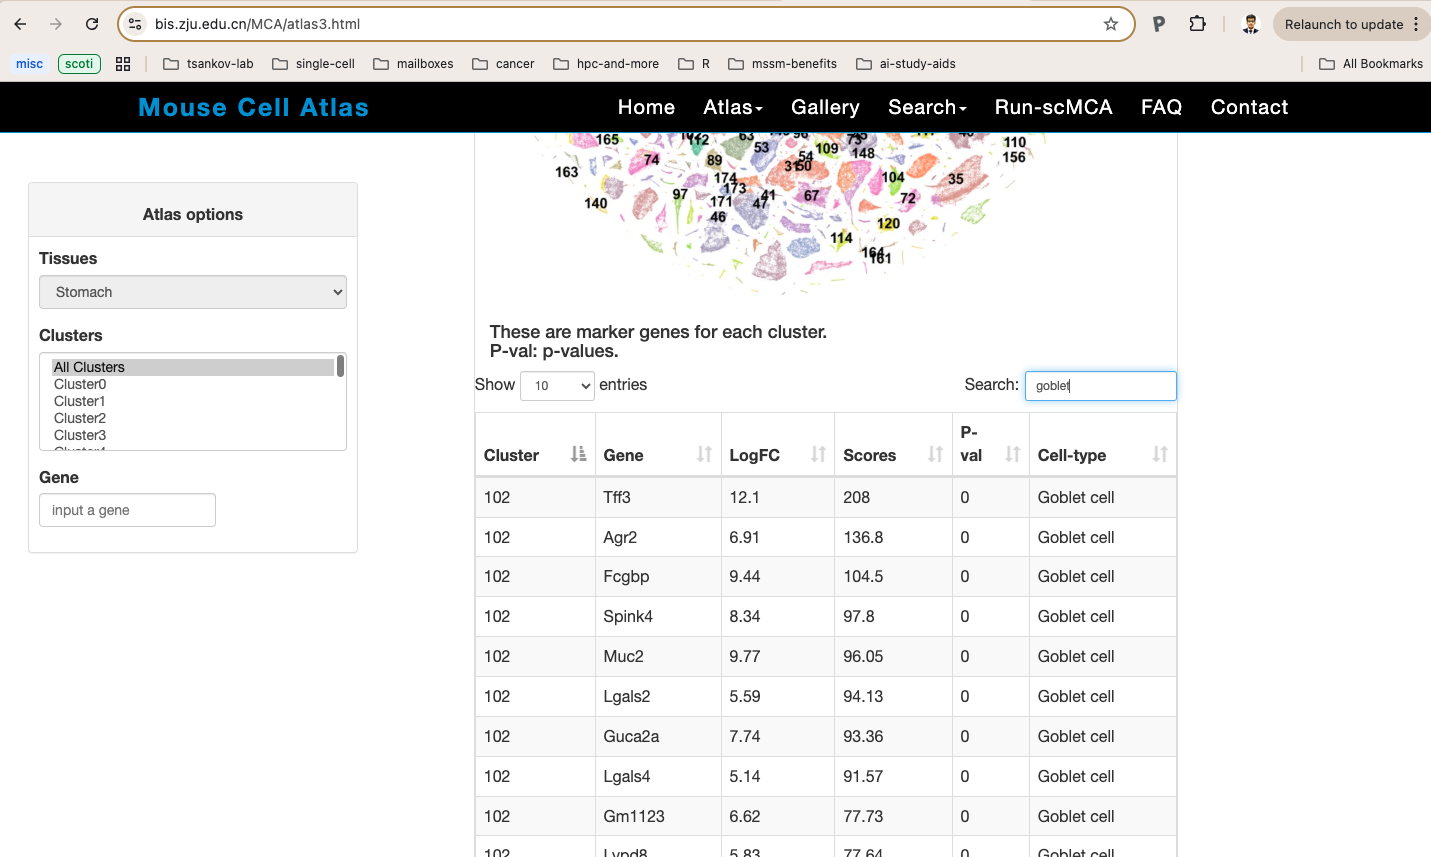

In [32]:
mouseMarkers.stomach_goblet <- c("Tff3", "Agr2", "Fcgbp", "Spink4", "Muc2")
mouseMarkers.stomach_goblet

[1] "Tff3"   "Agr2"   "Fcgbp"  "Spink4" "Muc2"